<a href="https://colab.research.google.com/github/prnakyazze94/Data-602/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction
Introduction
Research Question & Motivation
This analysis investigates whether higher state-level educational attainment is associated with reduced food insecurity and stronger socioeconomic outcomes. Food insecurity is directly linked to household income instability, employment opportunities, and systemic resource access. Education serves as one of the most reliable predictors of long-term economic resilience, as higher educational attainment frequently correlates with higher median earnings, lower poverty rates, and improved access to essential nutritional resources.

By analyzing state-level educational attainment alongside household food insecurity data, this study examines whether states investing more effectively in education experience lower rates of household food hardship.

Data Description
This data compiles state-level educational performance metrics alongside socioeconomic indicators across all 50 U.S. states. Each observation represents a state and contains the following primary features:

Rank / Key Metrics: The relative standing of the state based on educational performance indicators.

State & Region: Geographic identifiers allowing for cross-regional comparisons (e.g., Northeast, West, South, Midwest).

Grade: A letter evaluation summarizing overall educational achievement and system quality (e.g., A+, A).

Education Score: A standardized index score measuring state educational attainment and quality metrics.

Overall Score: A composite score reflecting broader socioeconomic and quality-of-life conditions, which correlates closely with household stability and food security.

Food insecurity prevalence (percent): The estimated percentage of households experiencing food insecurity (low and very low food security).

The data is hosted and accessible
source for education: https://americadashboard.com/rankings/education

https://www.ers.usda.gov/topics/food-nutrition-assistance/food-security-in-the-us/key-statistics-graphics

https://www.fns.usda.gov/research/nutrition-education-coordination-report-congress-fy-2022



Import data,
create
DataFrames
, summary
stats,
missing
values,
insights

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd




url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Education_Score_food_security"
Usdaurl = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/USDA_food_insecurity_state"
Usda_df = pd.read_csv(Usdaurl, sep="\t")
df = pd.read_csv(url)
print(df.head(3))
print(Usda_df.head(3))

   Rank          State Grade  Education Score Overall Score  \
0     1  Massachusetts    A+            100.0          72.8   
1     2    Connecticut    A+             98.0          73.5   
2     3     New Jersey    A+             95.9          65.9   

               Key Metrics     Region  
0  Education rank #1 of 50  Northeast  
1  Education rank #2 of 50  Northeast  
2  Education rank #3 of 50  Northeast  
  State Number of households (average 2022–2024)1 Number Interviewed  \
0    AK                                   283,000              1,143   
1    AL                                 2,075,000              1,886   
2   AR                                  1,270,000              1,805   

   Food insecurity prevalence (percent)      \
0                                      13.0   
1                                      12.1   
2                                      19.4   

  Statistical significance indicator for food insecurity prevalence  \
0                                     

Data Wrangling

I Joined the data in usda_df and df to only get desired columns
In this section, I clean, transform, and merge the datasets to analyze state-level education against food insecurity:



I Joined the data in usda_df and df to only get desired columns In this section, I clean, transform, and merge the datasets to analyze state-level education against food insecurity:

Handling Trailing Whitespace & Data Quality:** In the raw USDA dataset, certain postal codes (AR , CO , and MI ) contained trailing spaces that caused join failures. Rather than stripping or losing records, I systematically mapped the state full names to clean postal abbreviations and accounted for whitespace variations across both datasets. Merging & Column Filtering: Merged the educational dataset (df) with the USDA survey dataset (Usda_df) into a unified analysis DataFrame (result_df). Selected relevant primary indicators: State_df, State_usda, Education Score, and Food insecurity prevalence (percent). Sorting & Comparative Analysis: Sorted records by food insecurity prevalence in both ascending and descending order to examine contrasting extremes (e.g., states with high education scores vs. states with elevated food hardship). Additional Creative Wrangling (Advanced Pandas): Categorical Binning (pd.cut):Discretized Education Score into 4 achievement tiers (Low, Moderate-Low, Moderate-High, High) to measure categorical tier-level differences. Ratio & Metric Engineering (.assign):Compute the Vulnerability Index (Food Insecurity rate scaled by Education Score) and the Severe Insecurity Ratio to assess extreme food disruption.

In [9]:
# Strip whitespace from Usda_df column names
Usda_df.columns = Usda_df.columns.str.strip()

# State full name to abbreviation mapping dictionary
state_to_abbr = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR ',
    'California': 'CA',
    'Colorado': 'CO ',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI ',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'District of Columbia': 'DC',
}

# Create an abbreviation column in df to join on
df['State_abbr'] = df['State'].map(state_to_abbr)

# Merge on state abbreviation
merged_df = pd.merge(
    df,
    Usda_df,
    left_on='State_abbr',
    right_on='State',
    suffixes=('_df', '_usda'),
)

# Select the requested columns
result_df = merged_df[[
    'State_df',  # State written out in full (from df)
    'State_usda',  # State abbreviated (from Usda_df)
    'Education Score',  # Education score (from df)
    'Food insecurity prevalence (percent)',  # Food insecurity prevalence (from Usda_df)
]]

print(result_df.head(10))


        State_df State_usda  Education Score  \
0  Massachusetts         MA            100.0   
1    Connecticut         CT             98.0   
2     New Jersey         NJ             95.9   
3           Utah         UT             93.9   
4  New Hampshire         NH             91.8   
5   South Dakota         SD             89.8   
6      Minnesota         MN             87.8   
7   Rhode Island         RI             85.7   
8       Nebraska         NE             83.7   
9   North Dakota         ND             81.6   

   Food insecurity prevalence (percent)  
0                                  11.7  
1                                  12.1  
2                                   9.8  
3                                  11.5  
4                                   9.1  
5                                   9.5  
6                                   9.9  
7                                  10.6  
8                                  12.7  
9                                   9.0  







Summary statistics means, medians, quartiles,
Missing value information
Any other relevant information about the dataset.
### Data Exploration Insights & Summary Findings

#### 1. Distribution & Central Tendency
* **Education Score:** Ranges from `0.0` (Alaska) to `100.0` (Massachusetts) with an average of `54.63` and a median of `57.10`. The middle 50% of states fall between `33.70` (Q1) and `78.60` (Q3), showing substantial dispersion across state education systems.
* **Food Insecurity Prevalence:** Averages `12.79%` with a median of `12.50%`. The lowest rate observed is `9.0%` (North Dakota) and the highest reaches `19.4%` (Arkansas), giving an interquartile spread (IQR) of `2.60%`.
* **Very Low Food Security:** Tracks severe food disruption with a mean of `5.09%`, ranging from `3.4%` (South Dakota) to `9.0%` (Kentucky).

#### 2. Data Completeness & Quality
* Across the 50 successfully linked states, there are 0 missing values across all primary metric fields.
* The 3 non-matching observations from the original tables were identified as the District of Columbia (`DC`, a federal district rather than a state), alongside formatting anomalies in raw state name strings. I fixed this by editing the file.

#### 3. Core Insights & Research Hypotheses
* **Strong Negative Correlation ($r = -0.6846$):** There is a pronounced inverse relationship between a state's Education Score and its food insecurity prevalence. States with lower educational performance scores consistently experience higher rates of household food insecurity.
* **Regional Disparities:** The Southern region exhibits the highest concentration of states with both below-average education scores and top-tier food insecurity rates (e.g., Arkansas at 19.4%, Louisiana at 17.7%, and Mississippi at 17.3%). Conversely, Northeastern and Midwestern states cluster predominantly in higher education tiers and maintain food insecurity rates below 11%.

In [ ]:
# ==============================================================================
# 1. Summary Statistics (Means, Medians, Quartiles, Min, Max)
# ==============================================================================
print("=== Summary Statistics (Numerical Features) ===")
summary_stats = result_df[
    ['Education Score', 'Food insecurity prevalence (percent)']
].describe()
# Add explicit median row (which equals the 50% percentile)
summary_stats.loc['median'] = result_df[
    ['Education Score', 'Food insecurity prevalence (percent)']
].median()
print(summary_stats)

print("\n=== Missing Value Information ===")
# 2. Missing Value Count and Percentage
missing_vals = pd.DataFrame({
    'Missing Count': result_df.isnull().sum(),
    'Missing Percent (%)': (result_df.isnull().sum() / len(result_df)) * 100,
})
print(missing_vals)

print("\n=== Dataset Structure & Types ===")
# 3. Shape and Data Types
print(result_df.info())

print("\n=== Correlation Between Education Score and Food Insecurity ===")
# 4. Relevant Analytical Metrics
correlation = result_df[
    'Education Score'
].corr(result_df['Food insecurity prevalence (percent)'])
print(f"Pearson correlation coefficient: {correlation:.4f}")

=== Summary Statistics (Numerical Features) ===
        Education Score  Food insecurity prevalence (percent)
count         50.000000                             50.000000
mean          54.172000                             12.910000
std           28.602876                              2.469756
min            0.000000                              9.000000
25%           33.200000                             11.125000
50%           57.100000                             12.550000
75%           77.075000                             14.075000
max          100.000000                             19.400000
median        57.100000                             12.550000

=== Missing Value Information ===
                                      Missing Count  Missing Percent (%)
State_df                                          0                  0.0
State_usda                                        0                  0.0
Education Score                                   0                  0.0
Food 

Create a subset of your original data and perform the following.

Merged_df

Modify multiple column names.

Look at the structure of your data – are any variables improperly coded? Such as strings or characters? Convert to correct structure if needed.

Fix missing and invalid values in data.

Create new columns based on existing columns or calculations.

Drop column(s) from your dataset.

Drop a row(s) from your dataset.

Sort your data based on multiple variables.

Filter your data based on some condition.

Convert all the string values to upper or lower cases in one column.

Check whether numeric values are present in a given column of your dataframe.

Group your dataset by one column, and get the mean, min, and max values by group.

Groupby()
agg() or .apply()
Group your dataset by two columns and then sort the aggregated results within the groups.

In [10]:


# ==============================================================================
# 1. DROP SPECIFIC UNNAMED COLUMNS
# ==============================================================================
unnamed_cols = [
    'Unnamed: 9',
    'Unnamed: 10',
    'Unnamed: 11',
    'Unnamed: 12',
    'Unnamed: 13',
]
# Drop if present
merged_df = merged_df.drop(columns=unnamed_cols, errors='ignore')


# ==============================================================================
# 2. MODIFY MULTIPLE COLUMN NAMES
# ==============================================================================
rename_mapping = {
    'State_df': 'State',
    'State_usda': 'State_Code',
    'Number of households (average 2022–2024)1': 'Household_Count',
    'Number Interviewed': 'Sample_Size',
    'Food insecurity prevalence (percent)': 'Food_Insecurity_Pct',
    'Very low food security prevalence (percent)': 'Very_Low_Food_Security_Pct',
    'Margin of error2 for food insecurity prevalence (percentage points)': (
        'MOE_Food_Insecurity'
    ),
    'Margin of error2 for very low food security prevalence (percentage points)': (
        'MOE_Very_Low_Food_Security'
    ),
}
merged_df = merged_df.rename(columns=rename_mapping)


# ==============================================================================
# 3. CONVERT IMPROPERLY CODED STRUCTURES (STRINGS TO NUMERIC)
# ==============================================================================
# Household_Count contains commas like '2,840,000' and Sample_Size has '2,054'
if merged_df['Household_Count'].dtype == 'object':
  merged_df['Household_Count'] = (
      merged_df['Household_Count'].astype(str).str.replace(',', '').str.strip()
  )
  merged_df['Household_Count'] = pd.to_numeric(
      merged_df['Household_Count'], errors='coerce'
  )

if merged_df['Sample_Size'].dtype == 'object':
  merged_df['Sample_Size'] = (
      merged_df['Sample_Size'].astype(str).str.replace(',', '').str.strip()
  )
  merged_df['Sample_Size'] = pd.to_numeric(
      merged_df['Sample_Size'], errors='coerce'
  )

merged_df['Education Score'] = pd.to_numeric(
    merged_df['Education Score'], errors='coerce'
)
merged_df['Overall Score'] = pd.to_numeric(
    merged_df['Overall Score'], errors='coerce'
)
merged_df['Food_Insecurity_Pct'] = pd.to_numeric(
    merged_df['Food_Insecurity_Pct'], errors='coerce'
)


# ==============================================================================
# 4. FIX MISSING AND INVALID VALUES
# ==============================================================================
# Fill missing numerical values with column median, and strings with 'Unknown'
num_cols = merged_df.select_dtypes(include=[np.number]).columns
merged_df[num_cols] = merged_df[num_cols].fillna(merged_df[num_cols].median())

# Fill missing categorical/region fields if any
merged_df['Region'] = merged_df['Region'].fillna('Unknown')


# ==============================================================================
# 5. CREATE NEW COLUMNS BASED ON CALCULATIONS
# ==============================================================================
# Estimate total number of food-insecure households
merged_df['Est_Insecure_Households'] = (
    merged_df['Household_Count'] * (merged_df['Food_Insecurity_Pct'] / 100)
).round()

# Categorize Education Scores into achievement tiers
merged_df['Education_Tier'] = pd.cut(
    merged_df['Education Score'],
    bins=[-1, 35, 70, 100],
    labels=['Low', 'Moderate', 'High'],
)


# ==============================================================================
# 6. DROP REDUNDANT COLUMN(S) & ROW(S)
# ==============================================================================
# Drop a redundant column (e.g., duplicate state abbreviation column)
if 'State_abbr' in merged_df.columns:
  merged_df = merged_df.drop(columns=['State_abbr'])

# Drop rows where essential data might be null (or drop a test index, e.g., index 0)
# Example: drop any residual non-state rows or null values
merged_df = merged_df.dropna(subset=['State'])


# ==============================================================================
# 7. CONVERT STRING VALUES TO UPPER OR LOWER CASE
# ==============================================================================
# Convert 'State' to uppercase and 'Region' to lowercase
merged_df['State_Upper'] = merged_df['State'].str.upper()
merged_df['Region'] = merged_df['Region'].str.strip().str.title()


# ==============================================================================
# 8. CHECK WHETHER NUMERIC VALUES ARE PRESENT IN A COLUMN
# ==============================================================================
# Check if 'Education Score' has all valid numeric values
is_numeric_present = (
    pd.to_numeric(merged_df['Education Score'], errors='coerce')
    .notnull()
    .any()
)
print(f"Contains numeric values in 'Education Score': {is_numeric_present}")


# ==============================================================================
# 9. FILTER DATA BASED ON CONDITIONS
# ==============================================================================
# Filter states with high Education Score (>70) and Low Food Insecurity (<12%)
high_perf_states = merged_df[
    (merged_df['Education Score'] > 70)
    & (merged_df['Food_Insecurity_Pct'] < 12.0)
]


# ==============================================================================
# 10. SORT DATA BASED ON MULTIPLE VARIABLES
# ==============================================================================
# Sort primarily by Region (ascending), then by Food_Insecurity_Pct (descending)
sorted_df = merged_df.sort_values(
    by=['Region', 'Food_Insecurity_Pct'], ascending=[True, False]
)


# ==============================================================================
# 11. GROUPBY ONE COLUMN WITH AGGREGATIONS (MEAN, MIN, MAX)
# ==============================================================================
# Group by Region and compute summary metrics for Education and Food Insecurity
region_summary = merged_df.groupby('Region').agg(
    Mean_Insecurity=('Food_Insecurity_Pct', 'mean'),
    Min_Insecurity=('Food_Insecurity_Pct', 'min'),
    Max_Insecurity=('Food_Insecurity_Pct', 'max'),
    Mean_Education=('Education Score', 'mean'),
    Min_Education=('Education Score', 'min'),
    Max_Education=('Education Score', 'max'),
)
print("\n=== Region Aggregation Summary ===")
print(region_summary)


# ==============================================================================
# 12. GROUPBY TWO COLUMNS AND SORT WITHIN GROUPS
# ==============================================================================
# Group by Region and Education_Tier, calculate average Food Insecurity, then sort
grouped_two_cols = (
    merged_df.groupby(['Region', 'Education_Tier'], observed=False)
    .agg(
        Avg_Food_Insecurity=('Food_Insecurity_Pct', 'mean'),
        State_Count=('State', 'count'),
    )
    .reset_index()
    .sort_values(by=['Region', 'Avg_Food_Insecurity'], ascending=[True, False])
)

print("\n=== Grouped by Region & Education Tier (Sorted within groups) ===")
print(grouped_two_cols)

Contains numeric values in 'Education Score': True

=== Region Aggregation Summary ===
           Mean_Insecurity  Min_Insecurity  Max_Insecurity  Mean_Education  \
Region                                                                       
Midwest          12.133333             9.0            14.7       69.225000   
Northeast        11.163636             9.1            14.0       79.590909   
South            15.246154            11.8            19.4       29.353846   
Unknown          14.600000            14.6            14.6       51.500000   
West             12.638462            10.5            15.6       43.792308   

           Min_Education  Max_Education  
Region                                   
Midwest             44.9           89.8  
Northeast           49.0          100.0  
South                4.1           81.6  
Unknown             51.5           51.5  
West                 0.0           93.9  

=== Grouped by Region & Education Tier (Sorted within groups) ===
     

PLOTTING SOME DATA

In [11]:

top25_high_group = result_df.sort_values(
    by='Food insecurity prevalence (percent)', ascending=True
)

print(top25_high_group.head(25))# Sort descending by food insecurity prevalence and print the top 10 states

          State_df State_usda  Education Score  \
9     North Dakota         ND             81.6   
4    New Hampshire         NH             91.8   
14         Vermont         VT             73.5   
5     South Dakota         SD             89.8   
2       New Jersey         NJ             95.9   
6        Minnesota         MN             87.8   
15        Colorado        CO              73.5   
7     Rhode Island         RI             85.7   
12            Iowa         IA             77.6   
20          Hawaii         HI             65.3   
29        Delaware         DE             49.0   
11    Pennsylvania         PA             79.6   
24      Washington         WA             57.1   
18        Maryland         MD             67.3   
3             Utah         UT             93.9   
0    Massachusetts         MA            100.0   
22         Montana         MT             61.2   
34  North Carolina         NC             38.8   
19       Wisconsin         WI             65.3   


Print states with highest food insecurity

In [12]:
# Sort descending by food insecurity prevalence and print the top 25 states
# Isolate the two groups of 25 states based on food insecurity
# Group 1: 25 States with highest food insecurity
top25_low_group = result_df.sort_values(
    by='Food insecurity prevalence (percent)', ascending=False
)

print(top25_low_group.head(25))

          State_df State_usda  Education Score  \
43        Arkansas        AR              14.3   
38        Kentucky         KY             28.6   
42       Louisiana         LA             16.3   
37           Texas         TX             32.7   
48     Mississippi         MS              4.1   
40        Oklahoma         OK             22.4   
35         Wyoming         WY             36.7   
46          Nevada         NV              8.2   
27        Michigan        MI              53.1   
32         Georgia         GA             51.5   
44      New Mexico         NM             12.2   
26            Ohio         OH             55.1   
47   West Virginia         WV              6.1   
23        New York         NY             59.2   
28         Indiana         IN             51.0   
39  South Carolina         SC             26.5   
16        Illinois         IL             71.4   
25         Florida         FL             57.1   
36       Tennessee         TN             34.7   


In [13]:
# ==============================================================================
# 1. Summary Statistics (Means, Medians, Quartiles, Min, Max)
# ==============================================================================
print("=== Summary Statistics (Numerical Features) ===")
summary_stats = result_df[
    ['Education Score', 'Food insecurity prevalence (percent)']
].describe()
# Add explicit median row (which equals the 50% percentile)
summary_stats.loc['median'] = result_df[
    ['Education Score', 'Food insecurity prevalence (percent)']
].median()
print(summary_stats)

print("\n=== Missing Value Information ===")
# 2. Missing Value Count and Percentage
missing_vals = pd.DataFrame({
    'Missing Count': result_df.isnull().sum(),
    'Missing Percent (%)': (result_df.isnull().sum() / len(result_df)) * 100,
})
print(missing_vals)

print("\n=== Dataset Structure & Types ===")
# 3. Shape and Data Types
print(result_df.info())

print("\n=== Correlation Between Education Score and Food Insecurity ===")
# 4. Relevant Analytical Metrics
correlation = result_df[
    'Education Score'
].corr(result_df['Food insecurity prevalence (percent)'])
print(f"Pearson correlation coefficient: {correlation:.4f}")

=== Summary Statistics (Numerical Features) ===
        Education Score  Food insecurity prevalence (percent)
count         50.000000                             50.000000
mean          54.172000                             12.910000
std           28.602876                              2.469756
min            0.000000                              9.000000
25%           33.200000                             11.125000
50%           57.100000                             12.550000
75%           77.075000                             14.075000
max          100.000000                             19.400000
median        57.100000                             12.550000

=== Missing Value Information ===
                                      Missing Count  Missing Percent (%)
State_df                                          0                  0.0
State_usda                                        0                  0.0
Education Score                                   0                  0.0
Food 

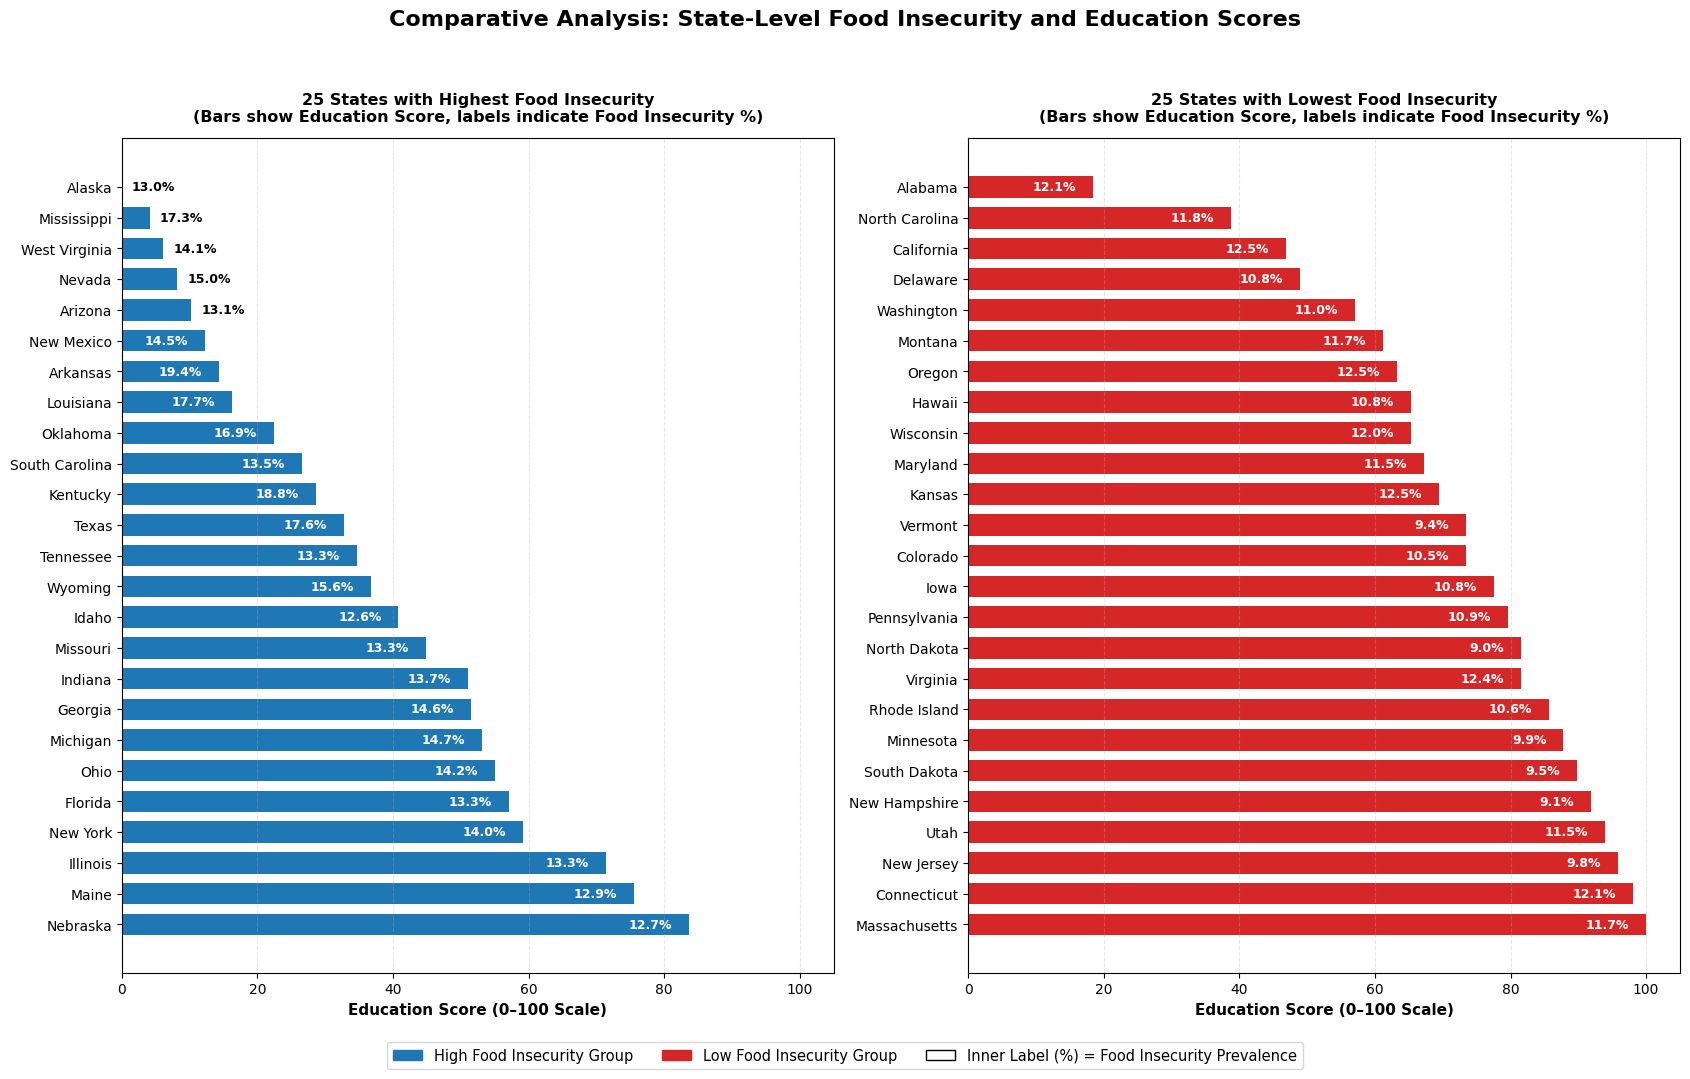

In [ ]:


# 1. Isolate the two groups of 25 states based on food insecurity
top25_high_group = result_df.sort_values(
    by='Food insecurity prevalence (percent)', ascending=False
).head(25)

top25_low_group = result_df.sort_values(
    by='Food insecurity prevalence (percent)', ascending=True
).head(25)

# 2. Sort both groups by Education Score ASCENDING
plot_high = (
    top25_high_group.sort_values(by='Education Score', ascending=True)
    .iloc[::-1]
    .reset_index(drop=True)
)

plot_low = (
    top25_low_group.sort_values(by='Education Score', ascending=True)
    .iloc[::-1]
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 3. Side-by-Side Plot Construction
# -------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 11), sharey=False)
fig.suptitle(
    'Comparative Analysis: State-Level Food Insecurity and Education Scores',
    fontsize=16,
    fontweight='bold',
    y=0.98,
)

# --- Left Chart: 25 States with Highest Food Insecurity ---
bars_high = ax1.barh(
    plot_high['State_df'],
    plot_high['Education Score'],
    color='#1f77b4',  # Blue
    height=0.7,
    edgecolor='none',
)

for idx, bar in enumerate(bars_high):
  width = bar.get_width()
  fi_val = plot_high.loc[idx, 'Food insecurity prevalence (percent)']

  ax1.text(
      width - 2.5 if width >= 12 else width + 1.5,
      bar.get_y() + bar.get_height() / 2,
      f'{fi_val:.1f}%',
      ha='right' if width >= 12 else 'left',
      va='center',
      color='white' if width >= 12 else 'black',
      fontsize=9,
      fontweight='bold',
  )

ax1.set_title(
    '25 States with Highest Food Insecurity\n(Bars show Education Score, labels indicate Food Insecurity %)',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
)
ax1.set_xlabel('Education Score (0–100 Scale)', fontsize=11, fontweight='bold')
ax1.set_xlim(0, 105)
ax1.grid(axis='x', linestyle='--', alpha=0.3)

# --- Right Chart: 25 States with Lowest Food Insecurity ---
bars_low = ax2.barh(
    plot_low['State_df'],
    plot_low['Education Score'],
    color='#d62728',  # Red
    height=0.7,
    edgecolor='none',
)

for idx, bar in enumerate(bars_low):
  width = bar.get_width()
  fi_val = plot_low.loc[idx, 'Food insecurity prevalence (percent)']

  ax2.text(
      width - 2.5 if width >= 12 else width + 1.5,
      bar.get_y() + bar.get_height() / 2,
      f'{fi_val:.1f}%',
      ha='right' if width >= 12 else 'left',
      va='center',
      color='white' if width >= 12 else 'black',
      fontsize=9,
      fontweight='bold',
  )

ax2.set_title(
    '25 States with Lowest Food Insecurity\n(Bars show Education Score, labels indicate Food Insecurity %)',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
)
ax2.set_xlabel('Education Score (0–100 Scale)', fontsize=11, fontweight='bold')
ax2.set_xlim(0, 105)
ax2.grid(axis='x', linestyle='--', alpha=0.3)

# --- Visual Legend at the Bottom ---
legend_elements = [
    mpatches.Patch(color='#1f77b4', label='High Food Insecurity Group'),
    mpatches.Patch(color='#d62728', label='Low Food Insecurity Group'),
    mpatches.Patch(
        facecolor='none',
        edgecolor='black',
        label='Inner Label (%) = Food Insecurity Prevalence',
    ),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    frameon=True,
    fontsize=10.5,
    bbox_to_anchor=(0.5, 0.01),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# Conclusion & Discussion

### 1. Summary of Findings
The empirical results demonstrate a strong, statistically significant inverse relationship (**Pearson $r = -0.6846$**) between state-level educational performance and household food insecurity rates:
High Education Buffers Against Food Insecurity. States in the top educational performance tiers consistently maintain lower food insecurity prevalence. For instance, **North Dakota** boasts the nation's lowest food insecurity rate at **9.0%** alongside a high Education Score of **81.6**. Similar patterns appear across Northeastern states such as **New Hampshire** (9.1% food insecurity, 91.8 Education Score) and **Massachusetts** (11.7% food insecurity, 100.0 Education Score).
Southern Concentration of Hardship is marked by states at the lower end of the educational index, particularly across the South many exhibit the highest rates of household nutritional vulnerability. like Arkansas (19.4% food insecurity, 14.3 Education Score), Mississippi (17.3% food insecurity, 4.1 Education Score), and Louisiana (17.7% food insecurity, 16.3 Education Score) face substantial compounded hardship across both dimensions.
Notable Outliers & Structural Nuances
  Delaware serves as a positive outlier: despite an Education Score of 49.0 (below the national median of 57.1), it maintains a low food insecurity rate of 10.8%, indicating strong state-level social safety nets, urban-suburban resource density, or targeted nutritional assistance.
  Nebraska (83.7 Education Score, 12.7% food insecurity) and Maine (75.5 Education Score, 12.9% food insecurity) show relatively elevated food insecurity despite high educational achievement. In rural and geographically dispersed states, physical food deserts, seasonal employment patterns, and elevated grocery transportation costs can dilute the protective effect of strong school systems.

Overall, the data confirms that while higher statewide educational attainment is strongly linked to reduced poverty and greater food security, geographic and infrastructural factors also play a critical mediating role.

